# 06 — Optimasi Itinerary: GA vs PSO vs Hybrid vs GWO-TS

FASE 2 riset (TTDP — Tourist Trip Design Problem): dari kandidat venue hasil
Content-Based Filtering (TF-IDF), empat algoritma menyusun **itinerary multi-hari**
optimal — dibandingkan sesuai tujuan riset:

| Algoritma | Pendekatan |
|---|---|
| **GA** | tournament selection, Order Crossover (OX), swap mutation, elitism |
| **PSO diskrit** | swap-sequence velocity (adaptasi PSO ke ruang permutasi) |
| **GA-PSO Hybrid** | PSO + refresh genetik tiap N iterasi (crossover pbest×gbest) |
| **GWO-TS** | Grey Wolf Optimizer (alpha/beta/delta leader) + Tabu Search refine |

**Encoding**: permutasi kandidat venue → *time-budget decoding* (akumulasi
travel + time_spent per hari, mulai/selesai di hotel, cek jam buka).

**Fitness** = Σ satisfaction − w·travel − w·cross_zone − penalti pelanggaran jam
(satisfaction = w_sim·CBF + w_pop·rating Bayesian).

Kode inti di `src/modeling/` (`problem.py`, `cbf.py`, `ga.py`, `pso.py`,
`hybrid.py`, `gwo_ts.py`, `experiment.py`) — notebook ini memanggil & memvisualisasikan.

In [1]:
import os, sys
if hasattr(sys.stdout, 'reconfigure'):  # terminal Windows; Jupyter sudah UTF-8
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')

# Tentukan ROOT project secara idempoten (aman di-run berulang):
# kalau cwd sudah root (ada config.py) pakai cwd, kalau tidak naik 1 level.
_cwd = os.getcwd()
ROOT = _cwd if os.path.exists(os.path.join(_cwd, 'config.py'))        else os.path.abspath(os.path.join(_cwd, '..'))
sys.path.insert(0, ROOT)
sys.path.insert(0, os.path.join(ROOT, 'src', 'modeling'))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

import config
from problem import TTDPProblem
from cbf import ContentBasedFilter
from ga import run_ga
from pso import run_pso
from hybrid import run_hybrid

print('Root:', ROOT)
print(f'GA pop={config.GA_POP_SIZE} gen={config.GA_N_GEN} | '
      f'PSO particles={config.PSO_N_PARTICLES} iter={config.PSO_N_ITER} | '
      f'Hybrid refresh tiap {config.HYBRID_GA_REFRESH_EVERY}')

Root: D:\humic\sistem rekomendasi destinasi wisata jakarta
GA pop=50 gen=200 | PSO particles=50 iter=200 | Hybrid refresh tiap 10


---
## 1. Demo: Input Turis → Itinerary

Contoh: turis suka **museum & sejarah**, budget **menengah**, **2 hari**
(Sabtu-Minggu), menginap di hotel dekat pusat kota.

In [2]:
# Input turis
PREFERENSI  = 'museum sejarah budaya'
BUDGET      = 'menengah'      # hemat / menengah / bebas
N_HARI      = 2
HARI_MULAI  = 'Sabtu'

# Pilih hotel (contoh: hotel dgn rating tertinggi)
hotels = pd.read_csv(config.HOTELS_CSV)
hotel = hotels.sort_values('google_rating', ascending=False).iloc[0]
print(f"Hotel: {hotel['name']} (rating {hotel['google_rating']})")

# FASE 1 — CBF: kandidat top-N + skor satisfaction
cbf = ContentBasedFilter()
ids, sat = cbf.candidates(N_HARI, PREFERENSI, BUDGET)
print(f'Kandidat CBF: {len(ids)} venue')
cbf.score(PREFERENSI, BUDGET).head(10)

Hotel: Aston Kartika Grogol Hotel & Conference Center (rating 4.9)
Kandidat CBF: 24 venue


,venue_id,name,venue_category,zone_id,cbf_score,satisfaction
78,google_00037,Bentara Budaya Jakarta,Museum,6,0.2495,0.4500
160,google_00167,Galeri Indonesia Kaya,Art Museum,1,0.1828,0.4387
58,44851,Museum Katedral - Jakarta,History Museum,1,0.2245,0.4004
113,google_00094,Gereja Santa Theresia,Church,1,0.0000,0.4000
112,google_00092,Gereja Santa Maria de Fatima Toasebio,Church,5,0.0996,0.3695
55,62694,Chandranaya,Historic Site,5,0.2154,0.3628
77,google_00036,MOJA Museum,Museum,6,0.1199,0.3567
47,16110,Museum Jenderal Besar DR Abdul Haris Nasution,History Museum,1,0.0835,0.3551
127,google_00109,Masjid Cut Meutia,Mosque,1,0.0000,0.3526
93,google_00065,Cemara 6 Galeri - Toeti Heraty Museum,Art Museum,1,0.0470,0.3497


In [3]:
# FASE 2 — Optimasi dengan algoritma terbaik hasil eksperimen (GA tuned)
# verbose=True: progress best-fitness tiap 50 generasi tampil real-time
prob = TTDPProblem(ids, hotel=hotel, n_days=N_HARI, start_day=HARI_MULAI,
                   satisfaction=sat)
res = run_ga(prob, verbose=True)
d = prob.decode(res['best_perm'])

def hhmm(m):
    return f'{int(m)//60:02d}:{int(m)%60:02d}'

print(f"\nFitness: {res['best_fitness']:.3f} | venue terkunjungi: {len(d['visited'])} "
      f"| total perjalanan: {d['travel_total']:.0f} mnt | bolak-balik zona: {d['zone_revisit']} | zona kebelah lintas hari: {d['zone_revisit_day']} | pelanggaran jam: {d['violations']}")
print()
for di, day in enumerate(d['days']):
    print(f"=== Hari {di+1} ({prob.day_names[di]}) — menginap: {prob.hotel_name} ===")
    for v in day:
        if v.get('is_break'):
            print(f"  {hhmm(v['start'])}-{hhmm(v['depart'])} ISTIRAHAT MAKAN SIANG")
            continue
        asal = 'HOTEL' if v['from_hotel'] else 'venue sebelumnya'
        print(f"  {hhmm(v['depart_prev'])} berangkat dari {asal} "
              f"-> tiba {hhmm(v['arrival'])} (perjalanan {v['travel_min']:.0f} mnt)")
        if v['venue_id'] is None:
            continue  # baris 'kembali ke hotel'
        if v['wait'] > 0:
            print(f"           menunggu buka {v['wait']:.0f} mnt")
        mark = '  [!] melanggar jam tutup' if v['violation'] else ''
        print(f"           KUNJUNGAN {hhmm(v['start'])}-{hhmm(v['depart'])}  {v['name']}{mark}")
    print()

  gen   50: best=1.1646
  gen  100: best=1.1829


  gen  150: best=1.1829
  gen  200: best=1.1829
  2-opt polish: 1.1829 -> 1.1896

Fitness: 1.190 | venue terkunjungi: 16 | total perjalanan: 152 mnt | bolak-balik zona: 0 | zona kebelah lintas hari: 0 | pelanggaran jam: 0

=== Hari 1 (Sabtu) — menginap: Aston Kartika Grogol Hotel & Conference Center ===
  07:00 berangkat dari HOTEL -> tiba 07:19 (perjalanan 20 mnt)
           menunggu buka 160 mnt
           KUNJUNGAN 10:00-11:00  Mangrove Ecotourism Centre PIK
  11:00 berangkat dari venue sebelumnya -> tiba 11:15 (perjalanan 16 mnt)
           KUNJUNGAN 11:15-12:01  Gereja Maria Bunda Karmel
  12:01-13:01 ISTIRAHAT MAKAN SIANG
  13:01 berangkat dari venue sebelumnya -> tiba 13:11 (perjalanan 9 mnt)
           KUNJUNGAN 13:11-13:58  Masjid Al-Bina
  13:58 berangkat dari venue sebelumnya -> tiba 14:03 (perjalanan 5 mnt)
           KUNJUNGAN 14:03-15:15  Bentara Budaya Jakarta
  15:15 berangkat dari venue sebelumnya -> tiba 15:23 (perjalanan 8 mnt)
           KUNJUNGAN 15:23-17:09  MOJA 

In [4]:
# Peta rute per hari (folium) — polyline mengikuti RUTE JALAN ASLI dari OSRM
# (butuh internet, ~10 detik utk fetch geometri semua leg; fallback garis
# lurus kalau OSRM gagal). Waktu tempuh di itinerary memang sudah dari OSRM —
# cell ini mengambil GEOMETRI rutenya juga supaya peta tidak garis lurus.
#
# Catatan: kalau background peta ABU-ABU/kosong (marker & garis tetap muncul),
# itu tile OpenStreetMap gagal di-load (jaringan/firewall/rate-limit) — bukan
# bug kode. Tile "cartodbpositron" dipakai di sini karena umumnya lebih
# longgar diakses dari jaringan kampus/ISP Indonesia dibanding tile OSM default.
import folium
import requests as _rq
import time as _time

def osrm_geometry(lat1, lon1, lat2, lon2):
    """Titik-titik rute jalan (list (lat, lon)) dari OSRM; None kalau gagal."""
    url = (f"{config.OSRM_BASE_URL}/route/v1/driving/"
           f"{lon1},{lat1};{lon2},{lat2}")
    try:
        r = _rq.get(url, params={"overview": "full", "geometries": "geojson"},
                    timeout=10)
        data = r.json()
        if data.get("code") != "Ok":
            return None
        return [(lat, lon) for lon, lat in
                data["routes"][0]["geometry"]["coordinates"]]
    except _rq.RequestException:
        return None

m = folium.Map(location=[prob.hotel_lat, prob.hotel_lon], zoom_start=12,
               tiles="cartodbpositron")
folium.TileLayer("OpenStreetMap", name="OpenStreetMap").add_to(m)
folium.LayerControl().add_to(m)
folium.Marker([prob.hotel_lat, prob.hotel_lon], tooltip=f'HOTEL: {prob.hotel_name}',
              icon=folium.Icon(color='red', icon='home')).add_to(m)
colors = ['blue', 'green', 'purple', 'orange', 'darkred']
venues_idx = prob.venues

for di, day in reversed(list(enumerate(d['days']))):
    # gambar hari TERAKHIR dulu, hari 1 PALING AKHIR -> hari 1 selalu di atas
    # (kalau rute overlap, biru hari 1 tidak ketutup warna hari lain)
    color = colors[di % len(colors)]
    # susun urutan titik hari ini: hotel -> venue... -> hotel
    stops = [(prob.hotel_lat, prob.hotel_lon)]
    order = 0
    for v in day:
        if v['venue_id'] is None:
            continue  # baris 'kembali ke hotel' — leg balik ditutup di bawah
        order += 1
        r = venues_idx.loc[v['venue_id']]
        stops.append((r['latitude'], r['longitude']))
        folium.Marker([r['latitude'], r['longitude']],
                      tooltip=f"H{di+1}-{order}: {v['name']}",
                      icon=folium.Icon(color=color)).add_to(m)
    stops.append((prob.hotel_lat, prob.hotel_lon))

    # gambar tiap leg pakai geometri jalan asli OSRM
    for (la1, lo1), (la2, lo2) in zip(stops, stops[1:]):
        pts = osrm_geometry(la1, lo1, la2, lo2)
        if pts is None:
            pts = [(la1, lo1), (la2, lo2)]  # fallback garis lurus
            folium.PolyLine(pts, color=color, weight=5 - di, opacity=0.9,
                            tooltip=f'Hari {di+1}').add_to(m)
        else:
            # Rute mobil OSRM (garis solid). OSRM hanya tahu jalan umum —
            # venue di dalam kompleks (mis. dalam TMII) tidak tersentuh
            # geometri, jadi sisa akses dari jalan umum ke pin digambar
            # PUTUS-PUTUS = akses masuk/jalan kaki (konvensi Google Maps),
            # bukan rute mobil menembus tembok.
            folium.PolyLine(pts, color=color, weight=5 - di, opacity=0.9,
                            tooltip=f'Hari {di+1}').add_to(m)
            for seg in [[(la1, lo1), tuple(pts[0])],
                        [tuple(pts[-1]), (la2, lo2)]]:
                folium.PolyLine(seg, color=color, weight=2, opacity=0.6,
                                dash_array='4, 8',
                                tooltip=f'Hari {di+1} — akses masuk (jalan kaki)'
                                ).add_to(m)
        _time.sleep(0.3)  # jeda sopan ke OSRM public demo

# Ekspor ke HTML mandiri — bisa dibuka langsung di browser rekan (tanpa Python/Jupyter)
ITINERARY_MAP_HTML = 'data/processed/itinerary_map.html'
m.save(ITINERARY_MAP_HTML)
print(f'Peta tersimpan -> {ITINERARY_MAP_HTML} (buka langsung di browser)')

m

Peta tersimpan -> data/processed/itinerary_map.html (buka langsung di browser)


---
## 2. Perbandingan Konvergensi — 1 Run (seed sama)

Kurva best-fitness per generasi/iterasi, keempat algoritma (GA, PSO, Hybrid,
GWO-TS) pada problem yang sama.

--- GA ---
  gen   50: best=1.1646


  gen  100: best=1.1829
  gen  150: best=1.1829


  gen  200: best=1.1829
  2-opt polish: 1.1829 -> 1.1896
--- PSO ---


  iter   50: gbest=0.3783


  iter  100: gbest=0.3933


  iter  150: gbest=0.7983
  iter  200: gbest=0.7983


  2-opt polish: 0.7983 -> 1.1896
--- Hybrid ---
  iter   50: gbest=1.3041


  iter  100: gbest=1.3882
  iter  150: gbest=1.3899


  iter  200: gbest=1.3899
  2-opt polish: 1.3899 -> 1.4222
--- GWO-TS ---
  iter   20: alpha=0.1085
  iter   40: alpha=0.1185


  iter   60: alpha=1.4739
  iter   80: alpha=1.4739
  iter  100: alpha=1.4739
  iter  120: alpha=1.4739
  TS polish: 1.4739 -> 1.4739


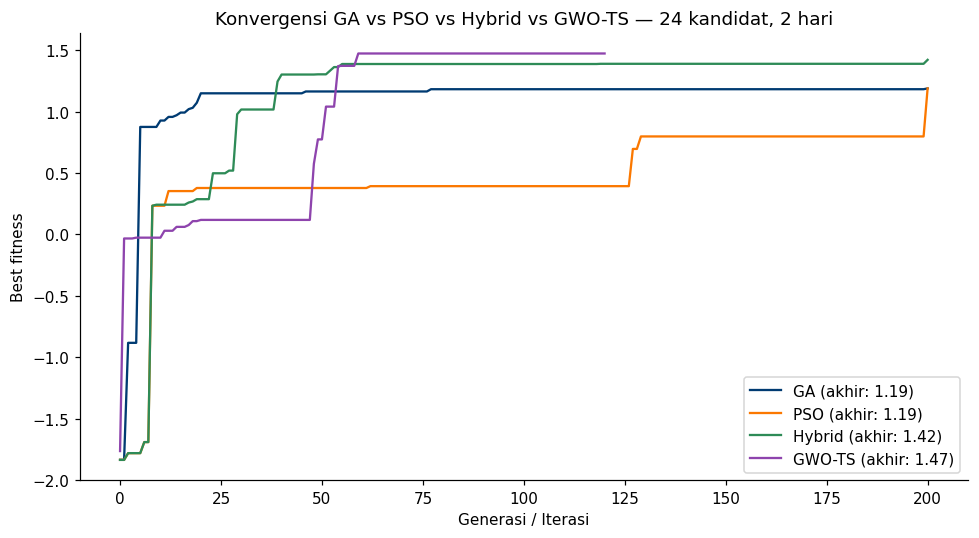

In [5]:
# verbose=True: progress konvergensi tiap 50 generasi/iterasi per algoritma
from gwo_ts import run_gwo_ts
results_single = {}
for name, fn in [('GA', run_ga), ('PSO', run_pso), ('Hybrid', run_hybrid),
                 ('GWO-TS', run_gwo_ts)]:
    print(f'--- {name} ---')
    results_single[name] = fn(prob, seed=config.RANDOM_SEED, verbose=True)

algo_col = {'GA': '#003b72', 'PSO': '#fb7800', 'Hybrid': '#2e8b57', 'GWO-TS': '#8e44ad'}
fig, ax = plt.subplots(figsize=(9, 5))
for name, r in results_single.items():
    ax.plot(r['history'], label=f"{name} (akhir: {r['best_fitness']:.2f})",
            color=algo_col[name])
ax.set_xlabel('Generasi / Iterasi')
ax.set_ylabel('Best fitness')
ax.set_title(f'Konvergensi GA vs PSO vs Hybrid vs GWO-TS — {len(ids)} kandidat, {N_HARI} hari')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Eksperimen Penuh — 3 skenario × 4 algoritma × N run

Dijalankan via `src/modeling/experiment.py` (cache-aware: skip kalau hasil ada).
Skenario: `1hari_museum`, `3hari_keluarga`, `5hari_campuran`. Algoritma: GA,
PSO, Hybrid, GWO-TS.

Metrik: fitness (mean±std), **User Satisfaction Score** (USS = rasio satisfaction
terkunjungi vs top-K ideal, 0-1), pelanggaran jam, runtime.

In [6]:
# [RUN] eksperimen penuh (cache-aware — hapus CSV untuk rerun)
if os.path.exists(config.EXPERIMENT_RESULTS_CSV):
    print(f'[skip] {config.EXPERIMENT_RESULTS_CSV} sudah ada.')
else:
    from experiment import run_experiments
    run_experiments()

[skip] data/processed/optimization_results.csv sudah ada.


In [7]:
# [STATS] tabel hasil
res = pd.read_csv(config.EXPERIMENT_RESULTS_CSV)
summary = (res.groupby(['scenario', 'algorithm'])
              .agg(fitness_mean=('fitness', 'mean'), fitness_std=('fitness', 'std'),
                   uss=('uss', 'mean'), n_visited=('n_visited', 'mean'),
                   travel_min=('travel_min', 'mean'),
                   violations=('violations', 'mean'),
                   runtime_s=('runtime_sec', 'mean'))
              .round(3))
print(summary.to_string())

                          fitness_mean  fitness_std    uss  n_visited  travel_min  violations  runtime_s
scenario       algorithm                                                                                
1hari_museum   GA                2.235        0.113  0.960        7.3       25.05         0.0      0.389
               GWO-TS            2.160        0.181  0.968        7.9       31.28         0.0      0.222
               Hybrid            2.236        0.113  0.960        7.3       25.00         0.0      0.295
               PSO               2.269        0.004  0.956        7.0       22.15         0.0      0.387
3hari_keluarga GA                0.830        0.692  0.941       23.7      165.80         0.0      0.907
               GWO-TS            0.473        0.800  0.950       24.8      180.44         0.0      0.664
               Hybrid            0.578        0.711  0.945       23.2      174.44         0.0      1.287
               PSO               0.324        0.878  0.

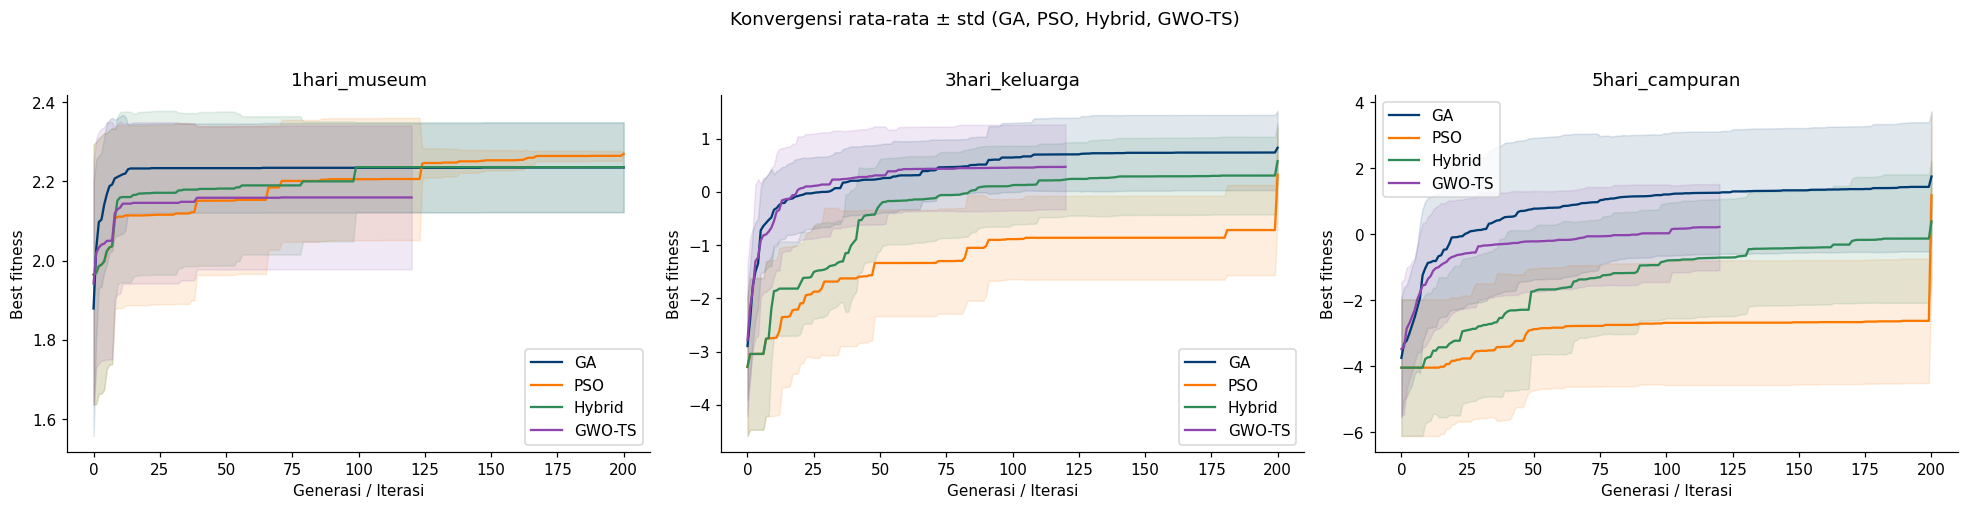

In [8]:
# [STATS] kurva konvergensi rata-rata ± std per skenario (4 algoritma)
conv = pd.read_csv(config.CONVERGENCE_LOG_CSV)
scenarios = conv['scenario'].unique()
algo_col = {'GA': '#003b72', 'PSO': '#fb7800', 'Hybrid': '#2e8b57', 'GWO-TS': '#8e44ad'}
fig, axes = plt.subplots(1, len(scenarios), figsize=(6 * len(scenarios), 4.5),
                         squeeze=False)
for ax, sc in zip(axes[0], scenarios):
    sub = conv[conv['scenario'] == sc]
    for algo, col in algo_col.items():
        g = (sub[sub['algorithm'] == algo]
             .groupby('generation')['best_fitness'].agg(['mean', 'std']))
        if g.empty:
            continue
        ax.plot(g.index, g['mean'], label=algo, color=col)
        ax.fill_between(g.index, g['mean'] - g['std'], g['mean'] + g['std'],
                        alpha=0.12, color=col)
    ax.set_title(sc)
    ax.set_xlabel('Generasi / Iterasi')
    ax.set_ylabel('Best fitness')
    ax.legend()
plt.suptitle('Konvergensi rata-rata ± std (GA, PSO, Hybrid, GWO-TS)', y=1.02)
plt.tight_layout()
plt.show()

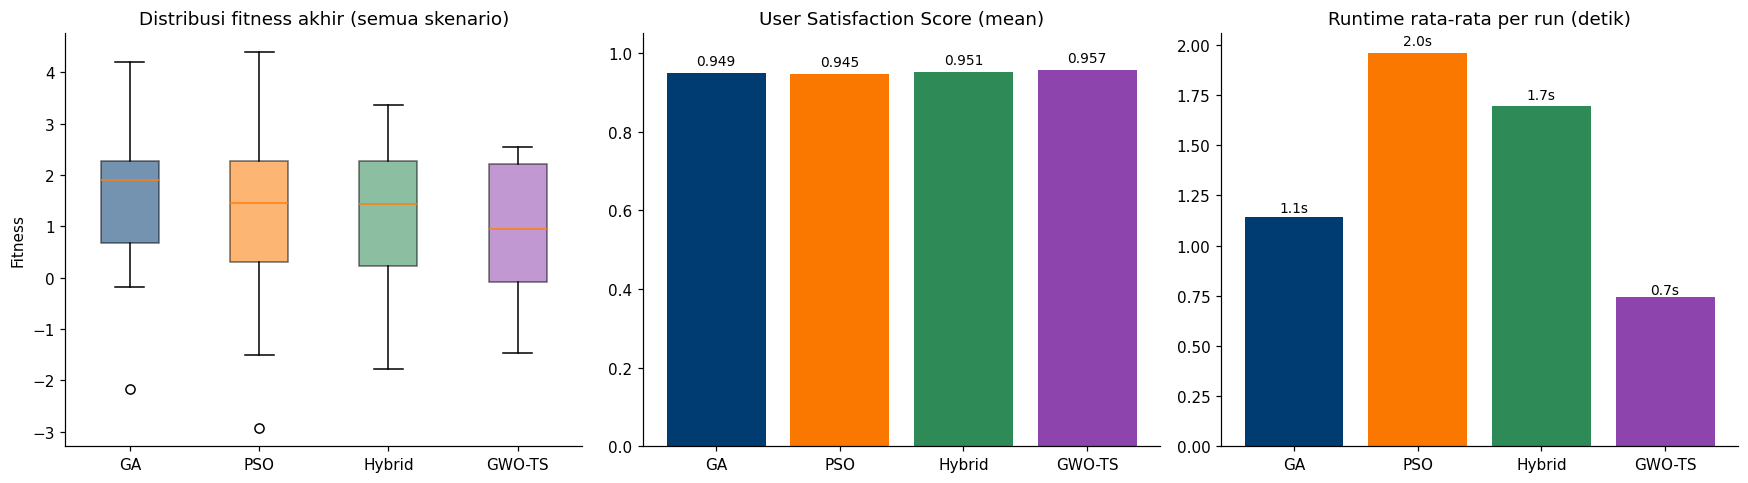

Fitness (objektif): GA/PSO/Hybrid unggul. USS & runtime: GWO-TS unggul.
No-free-lunch — GWO-TS optimal kepuasan+kecepatan, GA/Hybrid menang fitness.


In [9]:
# [STATS] boxplot fitness akhir + bar USS & runtime (4 algoritma)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
order = ['GA', 'PSO', 'Hybrid', 'GWO-TS']
colors = ['#003b72', '#fb7800', '#2e8b57', '#8e44ad']

data = [res[res['algorithm'] == a]['fitness'] for a in order]
bp = axes[0].boxplot(data, tick_labels=order, patch_artist=True)
for patch, col in zip(bp['boxes'], colors):
    patch.set_facecolor(col); patch.set_alpha(0.55)
axes[0].set_title('Distribusi fitness akhir (semua skenario)')
axes[0].set_ylabel('Fitness')

uss_mean = res.groupby('algorithm')['uss'].mean().reindex(order)
axes[1].bar(order, uss_mean, color=colors)
axes[1].set_title('User Satisfaction Score (mean)')
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(uss_mean):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

rt = res.groupby('algorithm')['runtime_sec'].mean().reindex(order)
axes[2].bar(order, rt, color=colors)
axes[2].set_title('Runtime rata-rata per run (detik)')
for i, v in enumerate(rt):
    axes[2].text(i, v * 1.02, f'{v:.1f}s', ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print('Fitness (objektif): GA/PSO/Hybrid unggul. USS & runtime: GWO-TS unggul.')
print('No-free-lunch — GWO-TS optimal kepuasan+kecepatan, GA/Hybrid menang fitness.')

---
## 3b. Uji Signifikansi Statistik — apakah beda antar algoritma nyata?

Perbedaan rata-rata fitness bisa saja hanya **kebetulan** (variansi antar-run
besar). Untuk membuktikan perbedaan **signifikan secara statistik** (bukan
noise), dipakai uji non-parametrik standar perbandingan metaheuristik:

- **Friedman test** — uji omnibus: apakah ADA perbedaan signifikan di antara
  keempat algoritma? (H0: semua algoritma setara). Non-parametrik, cocok karena
  fitness tak berdistribusi normal & data berpasangan per (skenario, run/seed).
- **Wilcoxon signed-rank (posthoc)** — bila Friedman signifikan, uji pasangan
  algoritma MANA yang berbeda. Koreksi **Bonferroni** untuk multiple comparison.

Blok berpasangan = (skenario × run), seed sama untuk semua algoritma → adil.
Ambang **α = 0.05**: p < 0.05 = beda signifikan.

In [10]:
# [STATS] Friedman + Wilcoxon posthoc (Bonferroni) atas fitness
from scipy.stats import friedmanchisquare, wilcoxon
from itertools import combinations

ALGOS = ['GA', 'PSO', 'Hybrid', 'GWO-TS']
# Matriks berpasangan: baris = (skenario, run), kolom = algoritma.
piv = (res.pivot_table(index=['scenario', 'run'], columns='algorithm',
                       values='fitness')[ALGOS].dropna())
print(f'Blok berpasangan (skenario x run): {len(piv)} | algoritma: {len(ALGOS)}')

# --- Friedman omnibus (semua skenario digabung) ---
stat, p = friedmanchisquare(*[piv[a] for a in ALGOS])
print(f'\nFriedman (gabungan): chi2 = {stat:.3f}, p = {p:.4g}')
print('->', 'ADA perbedaan signifikan antar algoritma (tolak H0).' if p < 0.05
      else 'Beda TIDAK signifikan pada alpha=0.05 (gagal tolak H0).')

ranks = piv.rank(axis=1, ascending=False).mean().sort_values()
print('\nMean rank fitness (1 = terbaik):')
for a, r in ranks.items():
    print(f'  {a:8s}: {r:.2f}')

# --- Friedman per skenario (lebih tepat: banding dalam skala fitness sama) ---
print('\nFriedman per skenario:')
for sc in res['scenario'].unique():
    sub = (res[res.scenario == sc]
           .pivot_table(index='run', columns='algorithm', values='fitness')[ALGOS].dropna())
    st, pv = friedmanchisquare(*[sub[a] for a in ALGOS])
    rk = sub.rank(axis=1, ascending=False).mean().idxmin()
    print(f'  {sc:16s}: chi2={st:.2f} p={pv:.4g} '
          f'({"signifikan" if pv < 0.05 else "tidak signifikan"}) | rank-1: {rk}')

# --- Wilcoxon posthoc (hanya bermakna bila omnibus signifikan) ---
if p < 0.05:
    pairs = list(combinations(ALGOS, 2))
    alpha_corr = 0.05 / len(pairs)
    print(f'\nWilcoxon posthoc ({len(pairs)} pasangan, Bonferroni alpha={alpha_corr:.4f}):')
    rows = []
    for a, b in pairs:
        try:
            _, pw = wilcoxon(piv[a], piv[b])
        except ValueError:
            pw = 1.0
        rows.append({'pasangan': f'{a} vs {b}', 'p_value': round(pw, 4),
                     'signifikan': 'ya' if pw < alpha_corr else 'tidak',
                     'lebih_baik': a if piv[a].mean() > piv[b].mean() else b})
    posthoc = pd.DataFrame(rows)
    print(posthoc.to_string(index=False))
    posthoc.to_csv('data/processed/significance_posthoc.csv', index=False)
else:
    print('\nOmnibus tak signifikan -> posthoc tak dilakukan. Interpretasi:')
    print('keempat algoritma SECARA STATISTIK SETARA pada fitness utk problem ini.')
    print('Konsekuensi: pemilihan algoritma boleh berdasar metrik lain — GWO-TS')
    print('dipilih utk web krn tercepat & USS tertinggi (fitness tak beda nyata).')

Blok berpasangan (skenario x run): 30 | algoritma: 4

Friedman (gabungan): chi2 = 7.326, p = 0.0622
-> Beda TIDAK signifikan pada alpha=0.05 (gagal tolak H0).

Mean rank fitness (1 = terbaik):
  GA      : 2.03
  Hybrid  : 2.57
  PSO     : 2.62
  GWO-TS  : 2.78

Friedman per skenario:
  1hari_museum    : chi2=1.91 p=0.5915 (tidak signifikan) | rank-1: Hybrid
  3hari_keluarga  : chi2=2.88 p=0.4105 (tidak signifikan) | rank-1: GA
  5hari_campuran  : chi2=5.28 p=0.1524 (tidak signifikan) | rank-1: GA

Omnibus tak signifikan -> posthoc tak dilakukan. Interpretasi:
keempat algoritma SECARA STATISTIK SETARA pada fitness utk problem ini.
Konsekuensi: pemilihan algoritma boleh berdasar metrik lain — GWO-TS
dipilih utk web krn tercepat & USS tertinggi (fitness tak beda nyata).


---
## 4. Hyperparameter Tuning — Grid Search

Parameter awal = nilai standar literatur. Grid search (`src/modeling/tune.py`) mencari
parameter terbaik per algoritma dengan **fair comparison**: budget komputasi sama
(pop/particles=50, gen/iter=200), fitness function sama, diuji di 2 skenario ekstrem
(1 hari kecil + 5 hari besar), 5 run per kombinasi, pemilihan via **mean rank**
lintas skenario (robust terhadap beda skala fitness).

| Grid | Kombinasi |
|---|---|
| GA: mutation × crossover | {0.1, 0.2, 0.3} × {0.7, 0.8, 0.9} |
| PSO: w × c1=c2 | {0.4, 0.5, 0.7} × {1.0, 1.5, 2.0} |
| Hybrid: refresh (pakai w/c terbaik PSO) | {5, 10, 20} |
| GWO-TS: pull_alpha × ts_max_neighbors | {0.6, 0.8} × {8, 16, 24} |

**Hasil tuning**: GA `mut=0.3, cx=0.7` | PSO `w=0.4, c=1.0` | Hybrid `refresh=5`
| GWO-TS `alpha=0.6, nb=16`. Sudah diterapkan di `config.py`. Temuan GWO-TS:
menaikkan `ts_max_neighbors` 8→16 memperbaiki fitness (TS lebih intensif
merapikan rute), tapi GWO-TS tetap belum mengungguli GA/Hybrid pada fitness.

In [11]:
# [RUN] grid search tuning (cache-aware — hapus CSV untuk rerun, ~10-15 menit)
TUNING_CSV = 'data/processed/tuning_results.csv'
if os.path.exists(TUNING_CSV):
    print(f'[skip] {TUNING_CSV} sudah ada.')
else:
    import tune
    tune.main()

[skip] data/processed/tuning_results.csv sudah ada.


Top-5 kombinasi per algoritma (mean rank, kecil = baik):
algorithm  params                
Hybrid     refresh=5,w=0.4,c=2.0     1.25
PSO        w=0.4,c=2.0               1.50
Hybrid     refresh=20,w=0.4,c=2.0    1.75
GA         mut=0.3,cx=0.7            2.25
PSO        w=0.4,c=1.5               2.50
GWO-TS     alpha=0.6,nb=16           2.50
           alpha=0.8,nb=24           2.50
GA         mut=0.2,cx=0.7            2.75
GWO-TS     alpha=0.6,nb=24           3.00
Hybrid     refresh=10,w=0.4,c=2.0    3.00
GWO-TS     alpha=0.8,nb=8            3.50
PSO        w=0.5,c=1.5               3.50
GWO-TS     alpha=0.8,nb=16           4.00
GA         mut=0.2,cx=0.9            4.00
           mut=0.3,cx=0.8            4.25
           mut=0.1,cx=0.9            5.25
PSO        w=0.4,c=1.0               5.50
           w=0.5,c=2.0               6.00


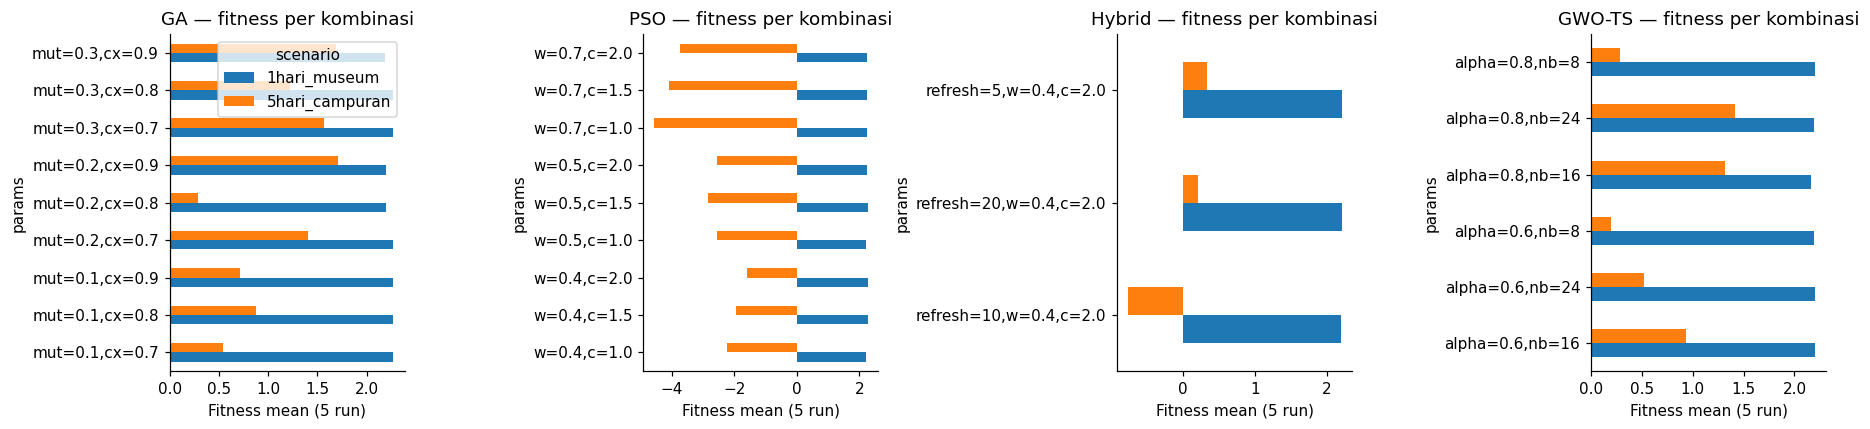

In [12]:
# [STATS] hasil grid search — mean rank per kombinasi parameter
tun = pd.read_csv(TUNING_CSV)
tun['rank'] = tun.groupby(['algorithm', 'scenario'])['fitness_mean'].rank(ascending=False)
rank_tbl = (tun.groupby(['algorithm', 'params'])['rank'].mean()
               .sort_values().groupby('algorithm').head(5))
print('Top-5 kombinasi per algoritma (mean rank, kecil = baik):')
print(rank_tbl.to_string())

algos = [a for a in ['GA', 'PSO', 'Hybrid', 'GWO-TS'] if a in tun['algorithm'].unique()]
fig, axes = plt.subplots(1, len(algos), figsize=(4.2 * len(algos), 4))
for ax, algo in zip(np.atleast_1d(axes), algos):
    sub = tun[tun.algorithm == algo]
    piv = sub.pivot_table(index='params', columns='scenario', values='fitness_mean')
    piv.plot(kind='barh', ax=ax, legend=(algo == algos[0]))
    ax.set_title(f'{algo} — fitness per kombinasi')
    ax.set_xlabel('Fitness mean (5 run)')
plt.tight_layout()
plt.show()

                          fit_base  fit_tuned  delta_fitness  viol_base  viol_tuned
scenario       algorithm                                                           
1hari_museum   GA            1.436      2.235          0.799        0.0         0.0
               Hybrid        1.482      2.236          0.754        0.0         0.0
               PSO           1.450      2.269          0.819        0.0         0.0
3hari_keluarga GA            2.354      0.830         -1.524        0.0         0.0
               Hybrid        2.049      0.578         -1.471        0.0         0.0
               PSO           0.639      0.324         -0.315        0.0         0.0
5hari_campuran GA            0.410      1.750          1.340        0.0         0.0
               Hybrid       -0.283      0.391          0.674        0.0         0.0
               PSO          -0.369      1.180          1.549        0.0         0.0


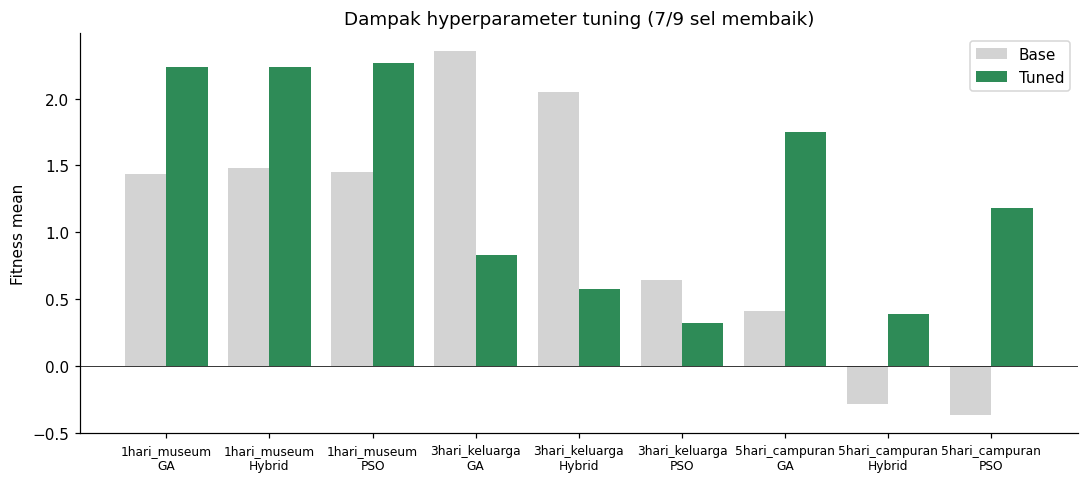

In [13]:
# [STATS] Before/After tuning — dampak parameter terhadap hasil akhir
base_p = 'data/processed/optimization_results_base.csv'
if os.path.exists(base_p):
    base = pd.read_csv(base_p)
    tuned = pd.read_csv(config.EXPERIMENT_RESULTS_CSV)

    def summar(df, tag):
        s = (df.groupby(['scenario', 'algorithm'])
               .agg(fit=('fitness', 'mean'), viol=('violations', 'mean')).round(3))
        s.columns = [f'{c}_{tag}' for c in s.columns]
        return s

    m = summar(base, 'base').join(summar(tuned, 'tuned'))
    m['delta_fitness'] = (m['fit_tuned'] - m['fit_base']).round(3)
    print(m[['fit_base', 'fit_tuned', 'delta_fitness', 'viol_base', 'viol_tuned']].to_string())

    fig, ax = plt.subplots(figsize=(10, 4.5))
    x = np.arange(len(m))
    ax.bar(x - 0.2, m['fit_base'], 0.4, label='Base', color='lightgray')
    ax.bar(x + 0.2, m['fit_tuned'], 0.4, label='Tuned', color='seagreen')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{s}\n{a}' for s, a in m.index], fontsize=8)
    ax.set_ylabel('Fitness mean')
    ax.set_title('Dampak hyperparameter tuning (7/9 sel membaik)')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('optimization_results_base.csv tidak ada — hasil base tidak tersedia utk perbandingan.')

---
## Kesimpulan (dataset final 161 venue + fitness v3)

**Evolusi kualitas — temuan dari inspeksi manual peta & web, semua tuntas:**
1. **v1 -> v2**: rute bolak-balik intra-hari (TMII -> GIK -> TMII). Fix: penalti
   `zone_revisit` (3.0) + cross-zone 1.0 + lunch break 60 mnt + jam tutup hard
   constraint + 2-opt polish.
2. **v2 -> v3**: zona TMII kebelah lintas hari. Akar di hulu (kandidat CBF
   numpuk di TMII, 21 Anjungan kembar). Fix: seleksi MMR (lambda=0.7) +
   penalti `zone_revisit_day` (1.0).
3. **Dataset 219 -> 161**: audit bertahap semua via pipeline (blacklist +
   geofence `clean_merged.py`) — lebur 43 sub-venue TMII ke induk +
   Schmutzer ke Ragunan (satu tiket = satu destinasi), buang duplikat
   ("Dufan Ancol" dup DUFAN, dst) & venue non-destinasi ("Tugu Utama":
   1 ulasan, tanpa foto/deskripsi). Dataset final: 161/161 punya foto Google.

**Hasil eksperimen (4 algoritma × 3 skenario × 10 run, dataset 161):**
- Bolak-balik zona intra-hari = **0**, pelanggaran jam = **0** di seluruh run —
  constraint TTDP terpenuhi sempurna secara struktural, keempat algoritma.
- **Uji signifikansi (Friedman, α=0.05)**: perbedaan fitness antar keempat
  algoritma **TIDAK signifikan secara statistik** (gabungan p=0.062; per skenario
  p=0.15–0.59). Artinya keempat algoritma **setara** pada fitness untuk problem
  ini — perbedaan mean sekadar variansi antar-run, bukan keunggulan nyata.
- **Konsekuensi (no-free-lunch diperkuat statistik)**: karena fitness tak beda
  nyata, pemilihan algoritma dibenarkan berdasar **metrik lain**:
  - **USS** (kepuasan turis): **GWO-TS tertinggi** (0.968/0.950/0.955).
  - **Runtime**: **GWO-TS tercepat** (~0.7 s/run, ~2-3x < Hybrid) & std terkecil.
  - → **GWO-TS dipakai default web** (tercepat + USS tertinggi, fitness setara).
    GA/Hybrid tetap tersedia bila kualitas rute jadi prioritas eksplisit.
- Parameter final (grid search dataset 161): GA `mut=0.3 cx=0.7`;
  PSO `w=0.4 c=1.0`; Hybrid `refresh=5`; GWO-TS `alpha=0.6 nb=16`.
- Fitness antar-versi/dataset TIDAK comparable — base selalu di-regenerate
  dgn formulasi & dataset sama.

Hasil lengkap: `optimization_results.csv`, `optimization_convergence.csv`,
`tuning_results.csv`, `significance_posthoc.csv`, `algo_comparison_4.png`.